In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import StepLR
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [33]:
# 물리 파라미터
RE    = 500.0
T0    = 5.0
T_END = 10.0
NX    = 120     # x 격자 수
NY    = 120     # y 격자 수
NT    = 51      # 시간 격자 수
LX    = 1.0     # 도메인 길이
LY    = 1.0
 
DX = LX / (NX - 1)
DY = LY / (NY - 1)
DT = (T_END - T0) / (NT - 1)
 
# 학습 파라미터
LR          = 5e-4
N_EPOCHS    = 100
ALPHA       = 1.0   # 연속 방정식 가중치
BETA        = 10.0  # 경계 조건 가중치
GAMMA       = 1.0   # 초기 조건 가중치
PRINT_EVERY = 1

In [ ]:
# ─────────────────────────────────────────────
# FNO 블록
# ─────────────────────────────────────────────
class SpectralConv3d(nn.Module):
    """3D Fourier Convolution Layer (x, y, t)"""
    def __init__(self, in_ch, out_ch, modes_x, modes_y, modes_t):
        super().__init__()
        self.in_ch   = in_ch    # 입력 채널 수 (예: 3 for (x, y, t))
        self.out_ch  = out_ch   # 출력 채널 수 (예: 3 for (u, v, p))
        self.modes_x = modes_x  # x 방향에서 사용할 푸리에 모드 수
        self.modes_y = modes_y  # y 방향에서 사용할 푸리에 모드 수
        self.modes_t = modes_t  # t 방향에서 사용할 푸리에 모드 수
 
        scale = 1 / (in_ch * out_ch)
        # 8개의 푸리에 코너 블록 (3D FFT)
        self.weights = nn.ParameterList([
            nn.Parameter(scale * torch.rand(in_ch, out_ch, modes_x, modes_y, modes_t, dtype=torch.cfloat))
            for _ in range(8)
        ])
 
    def compl_mul3d(self, x, w):
        return torch.einsum("bixyz,ioxyz->boxyz", x, w)
 
    def forward(self, x):
        B = x.shape[0]
        # FFT
        x_ft = torch.fft.rfftn(x, dim=[-3, -2, -1])
 
        mx, my, mt = self.modes_x, self.modes_y, self.modes_t
        out_ft = torch.zeros(B, self.out_ch,
                             x.size(-3), x.size(-2), x.size(-1)//2+1,
                             dtype=torch.cfloat, device=x.device)
 
        # 8개 코너에 가중치 적용
        out_ft[:, :,  :mx,  :my,  :mt] = self.compl_mul3d(x_ft[:, :,  :mx,  :my,  :mt], self.weights[0])
        out_ft[:, :, -mx:,  :my,  :mt] = self.compl_mul3d(x_ft[:, :, -mx:,  :my,  :mt], self.weights[1])
        out_ft[:, :,  :mx, -my:,  :mt] = self.compl_mul3d(x_ft[:, :,  :mx, -my:,  :mt], self.weights[2])
        out_ft[:, :, -mx:, -my:,  :mt] = self.compl_mul3d(x_ft[:, :, -mx:, -my:,  :mt], self.weights[3])
        out_ft[:, :,  :mx,  :my, -mt:] = self.compl_mul3d(x_ft[:, :,  :mx,  :my, -mt:], self.weights[4])
        out_ft[:, :, -mx:,  :my, -mt:] = self.compl_mul3d(x_ft[:, :, -mx:,  :my, -mt:], self.weights[5])
        out_ft[:, :,  :mx, -my:, -mt:] = self.compl_mul3d(x_ft[:, :,  :mx, -my:, -mt:], self.weights[6])
        out_ft[:, :, -mx:, -my:, -mt:] = self.compl_mul3d(x_ft[:, :, -mx:, -my:, -mt:], self.weights[7])
 
        return torch.fft.irfftn(out_ft, s=(x.size(-3), x.size(-2), x.size(-1)))
 
 
class FNOBlock3d(nn.Module):
    def __init__(self, width, modes_x, modes_y, modes_t):
        super().__init__()
        self.conv = SpectralConv3d(width, width, modes_x, modes_y, modes_t)
        self.w    = nn.Conv3d(width, width, 1)  # pointwise linear (잔차)
        self.norm = nn.InstanceNorm3d(width)
 
    def forward(self, x):
        return F.gelu(self.norm(self.conv(x) + self.w(x)))
 
 
class PINO_Cavity(nn.Module):
    """
    입력:  좌표 (x, y, t) → shape (B, 3, NX, NY, NT)
    출력:  (u, v, p)      → shape (B, 3, NX, NY, NT)
    """
    def __init__(self, width=32, modes_x=20, modes_y=20, modes_t=10, n_layers=4):
        super().__init__()
        self.lift    = nn.Conv3d(3, width, 1)
        self.blocks  = nn.ModuleList([
            FNOBlock3d(width, modes_x, modes_y, modes_t)
            for _ in range(n_layers)
        ])
        self.proj1   = nn.Conv3d(width, 128, 1)
        self.proj2   = nn.Conv3d(128, 3, 1)   # 출력: u, v, p
 
    def forward(self, x):
        x = self.lift(x)
        for block in self.blocks:
            x = block(x)
        x = F.gelu(self.proj1(x))
        return self.proj2(x)
 


In [35]:
# ─────────────────────────────────────────────
# Fourier 수치 미분
# ─────────────────────────────────────────────
def fourier_derivative(u, d, axis):
    """
    Fourier 스펙트럴 미분 (주기 도메인 가정, Fourier continuation 이용)
    u    : tensor (..., N, ...)
    d    : 격자 간격
    axis : 미분 방향 (-3=x, -2=y, -1=t)
    """
    N    = u.shape[axis]
    u_ft = torch.fft.rfft(u, dim=axis)
    k    = torch.fft.rfftfreq(N, d=d/(2*torch.pi)).to(u.device)
 
    # k 벡터를 u_ft 모양에 맞게 reshape
    shape = [1] * u.dim()
    shape[axis] = -1
    k = k.view(shape)
 
    du_ft = 1j * k * u_ft
    return torch.fft.irfft(du_ft, n=N, dim=axis)
 
 
def fourier_derivative2(u, d, axis):
    """2차 Fourier 미분"""
    N    = u.shape[axis]
    u_ft = torch.fft.rfft(u, dim=axis)
    k    = torch.fft.rfftfreq(N, d=d/(2*torch.pi)).to(u.device)
    shape = [1] * u.dim()
    shape[axis] = -1
    k = k.view(shape)
 
    d2u_ft = -(k**2) * u_ft
    return torch.fft.irfft(d2u_ft, n=N, dim=axis)
 
 

In [36]:
# ─────────────────────────────────────────────
# PDE Loss (Navier-Stokes, velocity-pressure)
# ─────────────────────────────────────────────
def navier_stokes_residual(uvp):
    """
    uvp: (B, 3, NX, NY, NT)  — u, v, p
 
    Navier-Stokes (비압축성, 와도-압력 formulation):
      ∂u/∂t + u·∂u/∂x + v·∂u/∂y = -∂p/∂x + (1/Re)·(∂²u/∂x² + ∂²u/∂y²)
      ∂v/∂t + u·∂v/∂x + v·∂v/∂y = -∂p/∂y + (1/Re)·(∂²v/∂x² + ∂²v/∂y²)
      ∂u/∂x + ∂v/∂y = 0   (연속 방정식)
    """
    u = uvp[:, 0:1]   # (B,1,NX,NY,NT)
    v = uvp[:, 1:2]
    p = uvp[:, 2:3]
 
    # --- 시간 미분 (유한 차분, 비주기) ---
    u_t = (u[:, :, :, :, 1:] - u[:, :, :, :, :-1]) / DT
    v_t = (v[:, :, :, :, 1:] - v[:, :, :, :, :-1]) / DT
 
    # 중간 시간 스텝에서의 값
    u_m = (u[:, :, :, :, 1:] + u[:, :, :, :, :-1]) / 2
    v_m = (v[:, :, :, :, 1:] + v[:, :, :, :, :-1]) / 2
    p_m = (p[:, :, :, :, 1:] + p[:, :, :, :, :-1]) / 2
 
    # --- 공간 미분 (Fourier, 주기 근사) ---
    u_x  = fourier_derivative(u_m, DX, axis=-3)
    u_y  = fourier_derivative(u_m, DY, axis=-2)
    v_x  = fourier_derivative(v_m, DX, axis=-3)
    v_y  = fourier_derivative(v_m, DY, axis=-2)
    p_x  = fourier_derivative(p_m, DX, axis=-3)
    p_y  = fourier_derivative(p_m, DY, axis=-2)
    u_xx = fourier_derivative2(u_m, DX, axis=-3)
    u_yy = fourier_derivative2(u_m, DY, axis=-2)
    v_xx = fourier_derivative2(v_m, DX, axis=-3)
    v_yy = fourier_derivative2(v_m, DY, axis=-2)
 
    nu = 1.0 / RE
 
    # NS 잔차
    res_u = u_t + u_m * u_x + v_m * u_y + p_x - nu * (u_xx + u_yy)
    res_v = v_t + u_m * v_x + v_m * v_y + p_y - nu * (v_xx + v_yy)
    res_c = u_x + v_y   # 연속 방정식
 
    return res_u, res_v, res_c

In [37]:
# ─────────────────────────────────────────────
# 경계 조건 Loss
# ─────────────────────────────────────────────
def boundary_loss(uvp):
    """
    No-slip BC:
      좌(x=0), 우(x=L), 하(y=0) : u=0, v=0
      상단(y=L)                  : u=1, v=0
    """
    u = uvp[:, 0]   # (B, NX, NY, NT)
    v = uvp[:, 1]
 
    loss = 0.0
    # 좌벽 x=0
    loss += torch.mean(u[:,  0, :, :]**2) + torch.mean(v[:,  0, :, :]**2)
    # 우벽 x=NX-1
    loss += torch.mean(u[:, -1, :, :]**2) + torch.mean(v[:, -1, :, :]**2)
    # 하벽 y=0
    loss += torch.mean(u[:, :,  0, :]**2) + torch.mean(v[:, :,  0, :]**2)
    # 상벽 y=NY-1: u=1, v=0
    loss += torch.mean((u[:, :, -1, :] - 1.0)**2) + torch.mean(v[:, :, -1, :]**2)
 
    return loss

def initial_condition_loss(uvp):
    """
    t=T0에서의 초기 조건: 정지 유동에서 시작 (u=0, v=0)
    단, 상벽 경계 조건은 이미 boundary_loss에서 처리
    """
    u = uvp[:, 0, :, :, 0]   # t=0 슬라이스
    v = uvp[:, 1, :, :, 0]
    return torch.mean(u**2) + torch.mean(v**2)
 

In [38]:
# ─────────────────────────────────────────────
# 좌표 그리드 생성
# ─────────────────────────────────────────────
def make_coords(batch_size=1):
    """
    (B, 3, NX, NY, NT) 형태의 좌표 텐서 생성
    채널: [x, y, t]
    """
    x = torch.linspace(0, LX, NX)
    y = torch.linspace(0, LY, NY)
    t = torch.linspace(T0, T_END, NT)
 
    # meshgrid
    gx, gy, gt = torch.meshgrid(x, y, t, indexing='ij')  # (NX, NY, NT)
 
    # 정규화 [-1, 1]
    gx = gx / LX
    gy = gy / LY
    gt = (gt - T0) / (T_END - T0)
 
    coords = torch.stack([gx, gy, gt], dim=0)             # (3, NX, NY, NT)
    coords = coords.unsqueeze(0).repeat(batch_size, 1, 1, 1, 1)  # (B, 3, NX, NY, NT)
    return coords.to(DEVICE)

In [39]:
# ─────────────────────────────────────────────
# 학습
# ─────────────────────────────────────────────
def train():
    print(f"Device: {DEVICE}")
    print(f"해상도: {NX}x{NY}x{NT}, Re={RE}, T=[{T0},{T_END}]")
    print("=" * 60)
 
    model = PINO_Cavity(
        width=32,
        modes_x=20,
        modes_y=20,
        modes_t=10,
        n_layers=4
    ).to(DEVICE)
 
    n_params = sum(p.numel() for p in model.parameters())
    print(f"모델 파라미터 수: {n_params:,}")
 
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = StepLR(optimizer, step_size=1000, gamma=0.5)
 
    coords = make_coords(batch_size=1)  # (1, 3, NX, NY, NT)
 
    history = {"total": [], "pde_u": [], "pde_v": [], "cont": [], "bc": [], "ic": []}
 
    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        optimizer.zero_grad()
 
        uvp = model(coords)   # (1, 3, NX, NY, NT)
 
        # PDE 잔차
        res_u, res_v, res_c = navier_stokes_residual(uvp)
        loss_pde_u = torch.mean(res_u**2)
        loss_pde_v = torch.mean(res_v**2)
        loss_cont  = torch.mean(res_c**2)
 
        # 경계 조건
        loss_bc = boundary_loss(uvp)
 
        # 초기 조건
        loss_ic = initial_condition_loss(uvp)
 
        # 총 손실
        loss = (loss_pde_u + loss_pde_v
                + ALPHA * loss_cont
                + BETA  * loss_bc
                + GAMMA * loss_ic)
 
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
 
        # 기록
        history["total"].append(loss.item())
        history["pde_u"].append(loss_pde_u.item())
        history["pde_v"].append(loss_pde_v.item())
        history["cont"].append(loss_cont.item())
        history["bc"].append(loss_bc.item())
        history["ic"].append(loss_ic.item())
 
        if epoch % PRINT_EVERY == 0 or epoch == 1:
            print(f"[Epoch {epoch:5d}] "
                  f"Total={loss.item():.4e} | "
                  f"PDE_u={loss_pde_u.item():.4e} | "
                  f"PDE_v={loss_pde_v.item():.4e} | "
                  f"Cont={loss_cont.item():.4e} | "
                  f"BC={loss_bc.item():.4e} | "
                  f"IC={loss_ic.item():.4e}")
 
    return model, coords, history

In [40]:
# ─────────────────────────────────────────────
# 시각화
# ─────────────────────────────────────────────
def visualize(model, coords, history, save_path="pino_cavity_result.png"):
    model.eval()
    with torch.no_grad():
        uvp = model(coords).cpu().squeeze(0)   # (3, NX, NY, NT)
 
    u = uvp[0].numpy()   # (NX, NY, NT)
    v = uvp[1].numpy()
    p = uvp[2].numpy()
 
    t_idx = -1  # 마지막 시간 스텝 (t=10)
 
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle(f"PINO Lid-Cavity Flow  Re={RE}  t={T_END}  [{NX}×{NY}×{NT}]", fontsize=14)
 
    extent = [0, LX, 0, LY]
 
    # u 속도
    im0 = axes[0, 0].imshow(u[:, :, t_idx].T, origin='lower', extent=extent, cmap='RdBu_r')
    axes[0, 0].set_title("u-velocity")
    plt.colorbar(im0, ax=axes[0, 0])
 
    # v 속도
    im1 = axes[0, 1].imshow(v[:, :, t_idx].T, origin='lower', extent=extent, cmap='RdBu_r')
    axes[0, 1].set_title("v-velocity")
    plt.colorbar(im1, ax=axes[0, 1])
 
    # 압력
    im2 = axes[0, 2].imshow(p[:, :, t_idx].T, origin='lower', extent=extent, cmap='viridis')
    axes[0, 2].set_title("pressure p")
    plt.colorbar(im2, ax=axes[0, 2])
 
    # 속도 크기
    speed = np.sqrt(u[:, :, t_idx]**2 + v[:, :, t_idx]**2)
    im3 = axes[1, 0].imshow(speed.T, origin='lower', extent=extent, cmap='hot_r')
    axes[1, 0].set_title("velocity magnitude")
    plt.colorbar(im3, ax=axes[1, 0])
 
    # 유선 (streamlines)
    x_arr = np.linspace(0, LX, NX)
    y_arr = np.linspace(0, LY, NY)
    axes[1, 1].streamplot(x_arr, y_arr, u[:, :, t_idx].T, v[:, :, t_idx].T,
                          density=1.5, color=speed.T, cmap='cool')
    axes[1, 1].set_title("streamlines")
    axes[1, 1].set_xlim(0, LX); axes[1, 1].set_ylim(0, LY)
 
    # 손실 곡선
    axes[1, 2].semilogy(history["total"],  label="Total",   lw=2)
    axes[1, 2].semilogy(history["pde_u"],  label="PDE u",   lw=1, alpha=0.7)
    axes[1, 2].semilogy(history["pde_v"],  label="PDE v",   lw=1, alpha=0.7)
    axes[1, 2].semilogy(history["cont"],   label="Cont.",   lw=1, alpha=0.7)
    axes[1, 2].semilogy(history["bc"],     label="BC",      lw=1, alpha=0.7)
    axes[1, 2].legend(fontsize=8)
    axes[1, 2].set_title("Loss history")
    axes[1, 2].set_xlabel("Epoch")
 
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\n결과 저장: {save_path}")
    return fig

Device: cuda
해상도: 120x120x51, Re=500.0, T=[5.0,10.0]
모델 파라미터 수: 131,080,963
[Epoch     1] Total=4.0735e+01 | PDE_u=8.3596e+00 | PDE_v=6.8500e+00 | Cont=1.2338e+01 | BC=1.3099e+00 | IC=8.8452e-02
[Epoch     2] Total=2.7567e+01 | PDE_u=3.3595e+00 | PDE_v=4.3978e+00 | Cont=8.7566e+00 | BC=1.0970e+00 | IC=8.2556e-02
[Epoch     3] Total=1.7136e+01 | PDE_u=1.6609e+00 | PDE_v=1.6853e+00 | Cont=3.6360e+00 | BC=1.0090e+00 | IC=6.3949e-02
[Epoch     4] Total=1.2244e+01 | PDE_u=7.8272e-01 | PDE_v=8.6010e-01 | Cont=1.4355e+00 | BC=9.1229e-01 | IC=4.3142e-02
[Epoch     5] Total=1.0793e+01 | PDE_u=7.7289e-01 | PDE_v=5.6049e-01 | Cont=9.9116e-01 | BC=8.4379e-01 | IC=3.0547e-02
[Epoch     6] Total=9.6470e+00 | PDE_u=9.3699e-01 | PDE_v=4.1059e-01 | Cont=7.9718e-01 | BC=7.4789e-01 | IC=2.3309e-02
[Epoch     7] Total=8.5643e+00 | PDE_u=8.4697e-01 | PDE_v=3.6698e-01 | Cont=6.7268e-01 | BC=6.6591e-01 | IC=1.8575e-02
[Epoch     8] Total=7.5136e+00 | PDE_u=7.4993e-01 | PDE_v=2.8083e-01 | Cont=4.5499e-01 | BC

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/pino_cavity_result.png'

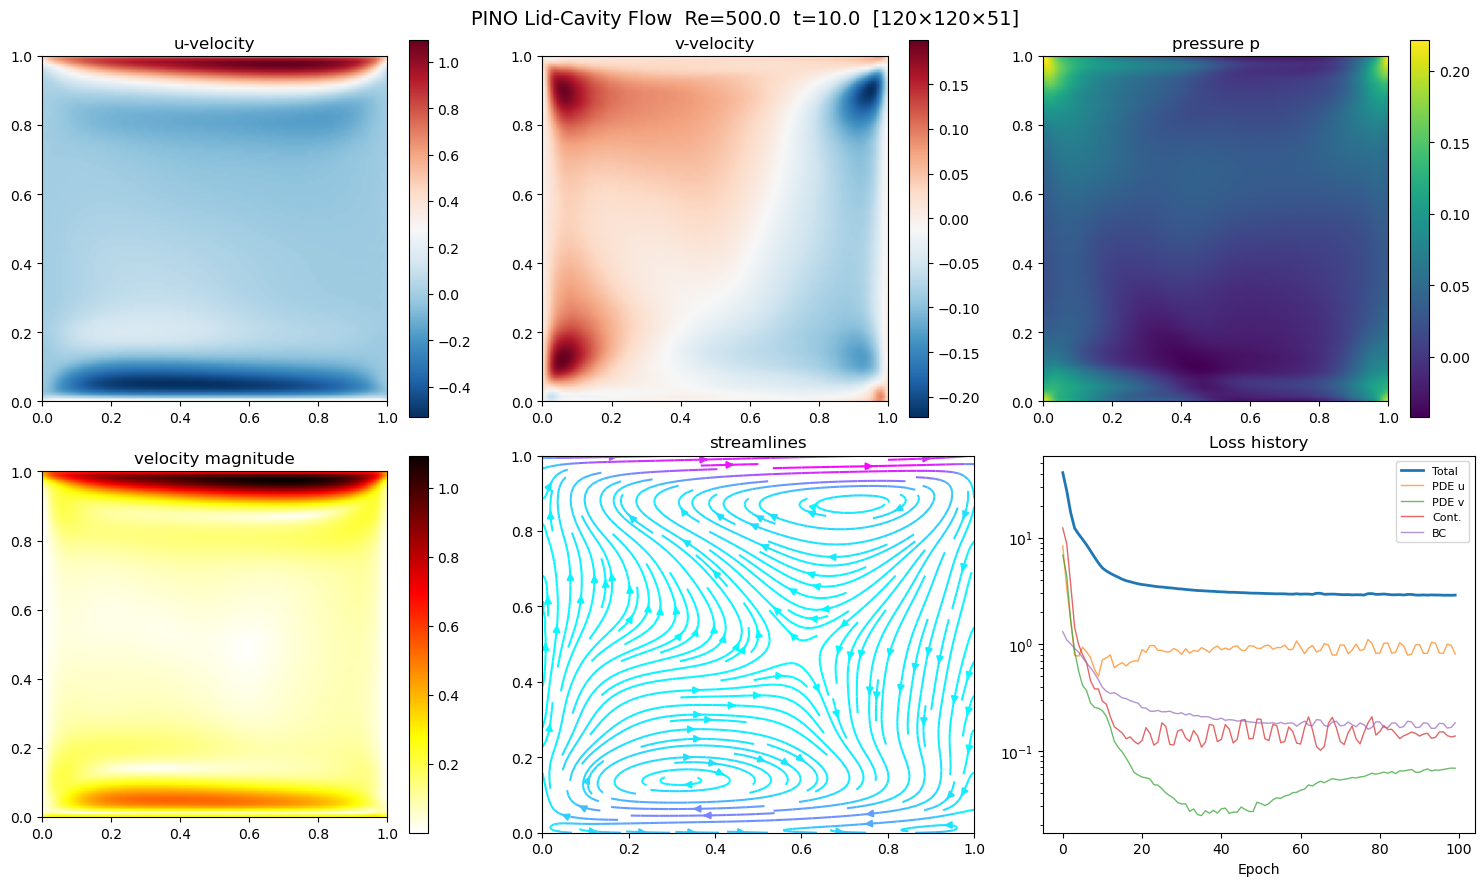

In [42]:
# ─────────────────────────────────────────────
# 메인
# ─────────────────────────────────────────────
if __name__ == "__main__":
    model, coords, history = train()
 
    # # 모델 저장
    # torch.save(model.state_dict(), "/home/claude/pino_cavity_model.pt")
    # print("모델 저장: pino_cavity_model.pt")
    
    # 시각화
    visualize(model, coords, history, save_path="/mnt/user-data/outputs/pino_cavity_result.png")
    print("완료!")